# Clustering d'Images avec Scikit-learn et Visualisation avec Streamlit

Le clustering est une technique d'apprentissage non supervisé qui permet de regrouper des données similaires en différents groupes ou clusters. Dans le contexte de l'analyse d'images, le clustering peut être utilisé pour segmenter des images, détecter des objets ou des régions d'intérêt, et comprendre la structure des données d'image. Ce TP vous guidera à travers le processus de clustering d'un ensemble d'images de chiffres manuscrits en utilisant l'algorithme K-Means et l'extraction de caractéristiques HOG et d'histogrammes de niveaux de gris. Vous visualiserez ensuite les résultats du clustering à l'aide de la bibliothèque Streamlit.


À la fin de ce TP, vous aurez une compréhension pratique du processus de clustering d'images, de l'extraction de caractéristiques, de l'évaluation des performances et de la visualisation des résultats à l'aide de Streamlit. Ces compétences sont précieuses dans de nombreux domaines tels que la vision par ordinateur, le traitement d'images médicales, l'analyse de données d'imagerie satellitaire, et bien d'autres.


In [2]:
%load_ext autoreload
%autoreload 2


In [3]:
from sklearn.preprocessing import StandardScaler
import os
import pandas as pd

from features import *
from clustering import *
from utils import *
from constant import *

import matplotlib.pyplot as plt



## Partie 1 : Création du modèle de clustering d'images
#### (fichier pipeline.py)

**1. Chargement des données d'images de chiffres manuscrits à partir du dataset Digits.**
   - Vous utiliserez le célèbre dataset Digitis qui contient des images de chiffres manuscrits. Ce dataset est souvent utilisé pour tester des algorithmes de reconnaissance de chiffres et d'apprentissage automatique.



In [4]:
print("##### Chargement des données ######")
base_images, labels_true = image_loader(IMAGES_DIR)
print(f"Nombre d'images chargées : {len(base_images)}")


##### Chargement des données ######
Nombre d'images chargées : 952


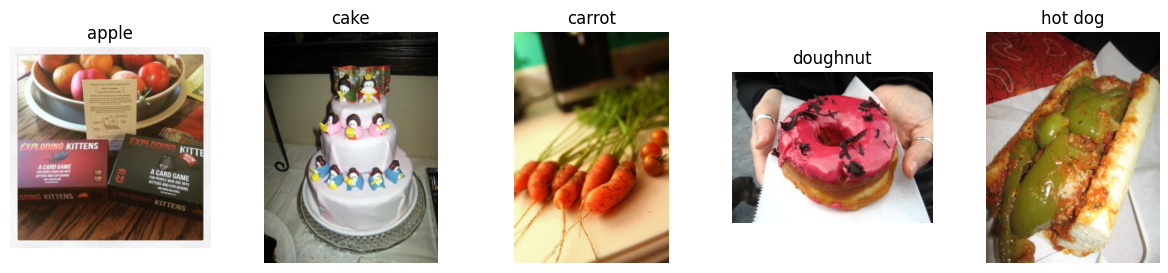

In [5]:
## show some images
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
## show 1 image each 100 image
for i in range(0, 500, 100):
    axes[i//100].imshow(base_images[i]['data'])
    axes[i//100].set_title(labels_true[i])
    axes[i//100].axis('off')
plt.show()

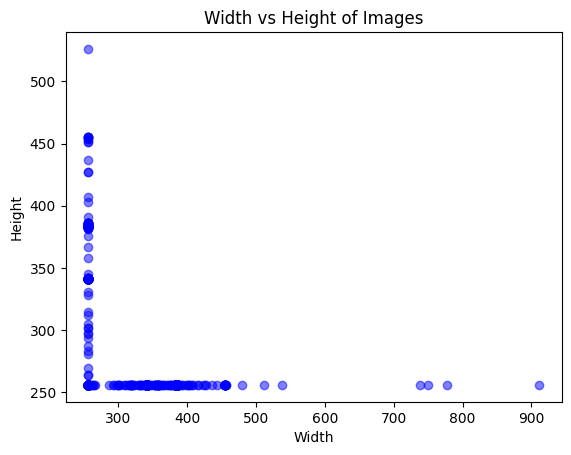

In [9]:
widths = [img["width"] for img in base_images]
heights = [img["height"] for img in base_images]
plt.scatter(widths, heights, c='blue', alpha=0.5)
plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Width vs Height of Images")
plt.show()

**2. Extraction des caractéristiques HOG (Histogrammes de Gradients Orientés) et des histogrammes de niveaux de gris à partir des images.**
   - Les caractéristiques HOG capturent les informations de gradient et de bords dans les images, ce qui les rend utiles pour la reconnaissance d'objets et de formes.
   - Les histogrammes de niveaux de gris représentent la distribution des intensités de pixels dans l'image, fournissant des informations sur la texture et les motifs.

**TODO :**
   - Implémentez les fonctions `compute_hog_descriptors` et `compute_gray_histograms` dans  le fichier `features.py`, utilisez respectivement les fonctions `hog` de  la librairie `skimage` et  `calcHist` de `cv2`.
   - lien HOG : https://scikit-image.org/docs/stable/auto_examples/features_detection/plot_hog.html
   - lien  histogrammes de niveaux de gris : https://pyimagesearch.com/2021/04/28/opencv-image-histograms-cv2-calchist/
   

In [73]:

print("\n\n ##### Extraction de Features ######")
print("- calcul features hog...")
descriptors_hog = compute_hog_descriptors(images)
print("- calcul features Histogram...")
descriptors_hist = compute_gray_histograms(images)

print(descriptors_hog.shape)
print(descriptors_hist.shape)




 ##### Extraction de Features ######
- calcul features hog...
- calcul features Histogram...
(1797, 8)
(1797, 16)


In [74]:
print("Shape check:")
print(f"  labels_true: {labels_true.shape}")
print(f"  descriptors_hog: {descriptors_hog.shape}")
print(f"  descriptors_hist: {descriptors_hist.shape}")
assert labels_true.shape[0] == descriptors_hog.shape[0], "Sample count mismatch for HOG"
assert labels_true.shape[0] == descriptors_hist.shape[0], "Sample count mismatch for histogram"
print("All shapes match!")


Shape check:
  labels_true: (1797,)
  descriptors_hog: (1797, 8)
  descriptors_hist: (1797, 16)
All shapes match!



**3. Application de l'algorithme K-Means sur les caractéristiques extraites pour obtenir les clusters.**
   - L'algorithme K-Means est un algorithme de clustering populaire qui partitionne les données en K clusters en minimisant la somme des carrés des distances entre les points de données et les centroïdes des clusters.
   
   
 
 **TODO :**
   - Dans le fichier `clustering.py` implémentez les fonctions `initialize_centers()`, `nearest_cluster()` et `fit()` du KMeans.
   

In [75]:
print("\n\n ##### Clustering ######")
n_clusters = 10
kmeans_hog = KMeans(n_clusters=n_clusters)
kmeans_hist = KMeans(n_clusters=n_clusters)

print("- calcul kmeans avec features HOG ...")
kmeans_hog.fit(np.array(descriptors_hog))
print("- calcul kmeans avec features Histogram...")
kmeans_hist.fit(np.array(descriptors_hist))



 ##### Clustering ######
- calcul kmeans avec features HOG ...
Converged after 28 iterations
- calcul kmeans avec features Histogram...
Converged after 25 iterations


In [76]:
kmeans_hog.labels_, kmeans_hist.labels_

(array([3, 5, 3, ..., 9, 3, 8], dtype=int64),
 array([5, 3, 6, ..., 6, 9, 5], dtype=int64))

**4. Évaluation des performances du clustering en utilisant des métriques telles que la pureté, l'entropie, et les scores Rand et Mutual Information.**
   - La pureté mesure la fraction d'exemples de cluster qui sont membres du cluster majoritaire.
   - L'entropie est une mesure de désordre ou d'impureté dans les clusters.
   - Le score Rand mesure la similarité entre deux partitions en comparant les paires d'exemples.
   - Le score Mutual Information évalue la quantité d'information partagée entre deux partitions.


In [77]:

print("\n\n##### Résultat ######")
metric_hist = show_metric(labels_true, kmeans_hist.labels_, descriptors_hist, bool_show=True, name_descriptor="HISTOGRAM", bool_return=True)
print("\n\n")
metric_hog = show_metric(labels_true, kmeans_hog.labels_, descriptors_hog,bool_show=True, name_descriptor="HOG", bool_return=True)




##### Résultat ######
########## Métrique descripteur : HISTOGRAM
Adjusted Rand Index: 0.06316098048671613
Jaccard Index: 0.0488436444160588
Homogeneity: 0.13369733121097058
Completeness: 0.13548015226257873
V-measure: 0.13458283773087296
Silhouette Score: 0.06489614133799877
Adjusted Mutual Information: 0.12586044048233894



########## Métrique descripteur : HOG
Adjusted Rand Index: 0.07203508892857141
Jaccard Index: 0.028076890110225516
Homogeneity: 0.1640217318319141
Completeness: 0.17543180151546015
V-measure: 0.1695350030339047
Silhouette Score: 0.14670300067641312
Adjusted Mutual Information: 0.16080453518223617


**5. Conversion des données de clustering au format requis pour la visualisation avec Streamlit.**


In [79]:
list_dict = [metric_hist,metric_hog]
df_metric = pd.DataFrame(list_dict)

scaler = StandardScaler()
descriptors_hist_norm = scaler.fit_transform(descriptors_hist)
descriptors_hog_norm = scaler.fit_transform(descriptors_hog)

#conversion vers un format 3D pour la visualisation
x_3d_hist = conversion_3d(descriptors_hist_norm)
x_3d_hog = conversion_3d(descriptors_hog_norm)

# création des dataframe pour la sauvegarde des données pour la visualisation
df_hist = create_df_to_export(x_3d_hist, labels_true, kmeans_hist.labels_)
df_hog = create_df_to_export(x_3d_hog, labels_true, kmeans_hog.labels_)

# Vérifie si le dossier existe déjà
if not os.path.exists(PATH_OUTPUT):
    # Crée le dossier
    os.makedirs(PATH_OUTPUT)

# sauvegarde des données
df_hist.to_excel(PATH_OUTPUT+"/save_clustering_hist_kmeans.xlsx")
df_hog.to_excel(PATH_OUTPUT+"/save_clustering_hog_kmeans.xlsx")
df_metric.to_excel(PATH_OUTPUT+"/save_metric.xlsx")




TypeError: TSNE.__init__() got an unexpected keyword argument 'n_iter'

***6. Création du fichier pipeline.py*** 
- Mettez au propre le code dans le fichier pipeline.py
- Puis exécutez :  `python pipeline.py `


## Partie 2 : Visualisation des résultats du clustering avec Streamlit
### (fichier dashboad_clustering.py)

Cette partie constituera le rendu final du TP. Nous développerons une application Streamlit pour visualiser et analyser les résultats du clustering.

L'application permettra de :

***1. Visualisation 3D du clustering***
- Nous créerons une visualisation 3D interactive des clusters obtenus, avec la possibilité de mettre en évidence un cluster spécifique et d'afficher des exemples d'images appartenant à ce cluster.

***TODO :***
- Utilizer la fonction `scatter_3d()` pour faire un plot 3D du clustering.
- lien : https://plotly.com/python/3d-scatter-plots/




In [ ]:
import matplotlib.pyplot as plt
import plotly.express as px


***2. Métriques d'évaluation***
- Nous calculerons et afficherons diverses métriques d'évaluation, telles que le score AMI (Adjusted Mutual Information), pour quantifier la qualité du clustering obtenu avec chaque descripteur.

***TODO :*** 
- Utilisez la fonction `px.bar()` pour afficher un histogramme du score AMI.
- lien : https://plotly.com/python/horizontal-bar-charts/

In [ ]:
graph_size = 300


In [ ]:
df_metric

,ami,ari,silhouette,homogeneity,completeness,v_measure,jaccard,descriptor,name_model
0,0.134182,0.068122,0.063914,0.141543,0.144184,0.142851,0.057647,HISTOGRAM,kmeans
1,0.415635,0.314030,0.110121,0.417808,0.425218,0.421480,0.081767,HOG,kmeans


***3. Finalisation du fichier dashboard_clustering.py***

***TODO :***
- Ajoutez les graphiques dans le fichier, puis lancez la commande :  `streamlit run dashboard_clustering.py `